**06 — Final full-phase sparse-slice MedGS reconstruction**

This notebook runs the final MedGS reconstruction experiment for patient 117, respiratory phase 0%.

The task is **spatial sparse-slice interpolation inside one 3D CT phase**. It is not temporal interpolation between respiratory phases. MedGS receives only a sparse subset of axial CT slices and their corresponding binary tumor masks, learns a joint Gaussian representation, and reconstructs the missing slices.

The model configuration was selected earlier on a smaller region around the tumor. Here it is transferred **unchanged to the complete phase**. The purpose of this notebook is therefore final evaluation, not further hyperparameter tuning.

Selected configuration:

- `stride = 3`;
- `poly_degree = 7`;
- `lambda_img = 1`;
- `lambda_seg = 2`;
- Dice-augmented segmentation loss;
- background-aware in-between segmentation penalty;
- 30,000 training iterations.

The SDF baseline is intentionally left for the subsequent comparison notebook.

# 1. Data and sparse sampling

The complete phase contains **147 axial CT slices**, indexed `0..146`.

The regular sparse sequence is aligned so that the same tumor slices used in the local experiments remain observed:

`2, 5, 8, ..., 146`

Slice `0` is additionally included as an observed boundary slice. This gives:

- **50 observed slices** used for training;
- **97 held-out slices** reconstructed by MedGS;
- both volume boundaries observed, so the final result does not rely on extrapolation beyond the available CT volume.

The first interval `0 -> 2` is therefore two slices long. All subsequent observed frames are separated by three original CT slice indices.

Around the tumor the sampling pattern is:

| CT slice | 83 | 84 | 85 | 86 | 87 | 88 | 89 | 90 | 91 | 92 | 93 | 94 | 95 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| status | O | R | R | O | R | R | O | R | R | O | R | R | O |
| GT tumor | no | no | no | yes | yes | yes | yes | yes | yes | yes | no | no | no |

`O` means **observed during training**, while `R` means **held out and reconstructed**.

The observed positive tumor masks are therefore slices `86`, `89` and `92`. The clinically important held-out tumor slices are `87`, `88`, `90` and `91`.

The CT input uses the prepared `denoised` representation. Segmentation input is a filled binary mask: background `0`, tumor `255`. Ground-truth masks of held-out slices are used only for evaluation after reconstruction.

In [1]:
from pathlib import Path
from typing import Any

import json
import os
import shutil
import subprocess
import sys

import numpy as np
import pandas as pd
import torch
from PIL import Image
from IPython.display import display

from medgs4d.data import (
    grayscale_to_rgb_uint8,
    load_phase_volume,
    load_study_manifest,
    window_hu_to_uint8,
)
from medgs4d.evaluation import calculate_reconstruction_metrics
from medgs4d.mesh_transfer import evaluate_mesh_against_reference
from medgs4d.meshes import (
    TriangleMesh,
    binary_dice,
    binary_iou,
    load_mesh_npz,
    write_ply,
)
from medgs4d.rtstruct import load_geometry
from medgs4d.sparse_joint_visualization import (
    show_sparse_joint_anatomy_3d,
    show_sparse_joint_slice_browser,
)

STACK_ROOT = Path("/home/jovyan/shared/mtm_medgs_stack")
MEDGS_REPO = STACK_ROOT / "repo" / "MedGS"
STUDY_DIR = (
    STACK_ROOT
    / "data"
    / "tcia_4d_lung"
    / "prepared"
    / "patient117_20001024_annotated"
)

PHASE = 0.0
REPRESENTATION = "denoised"

SLICE_STRIDE = 3
ITERATIONS = 30_000
POLY_DEGREE = 7
BATCH_SIZE = 3

LAMBDA_IMG = 1.0
LAMBDA_SEG = 2.0
DICE_WEIGHT = 1.0
BG_INTER_WEIGHT = 0.5

ALPHA_MIN = 0.2
ALPHA_MAX = 0.8

MASK_THRESHOLD = 150
MESH_THRESHOLD = 0
RENDER_INTERP = 6
RENDER_CHUNKS = 4

TEST_ITERATIONS = [5_000, 10_000, 15_000, 20_000, 25_000, 30_000]
TRAIN_HISTORY_INTERVAL = 100

TUMOR_START = 86
TUMOR_END = 92

FORCE_TRAIN = False

PHASE_TAG = f"{int(PHASE):02d}"
PHASE_DIR = (
    STUDY_DIR
    / "rtstruct_mesh"
    / "tumor_4d"
    / f"phase_{PHASE_TAG}"
)

FULL_ROOT = (
    STACK_ROOT
    / "results"
    / "canonical"
    / STUDY_DIR.name
    / (
        f"phase{PHASE_TAG}_joint_full_stride{SLICE_STRIDE}_"
        f"poly{POLY_DEGREE}_lseg2_bginter_v13"
    )
)

IMG_DATASET = FULL_ROOT / "dataset_img"
MASK_DATASET = FULL_ROOT / "dataset_mask"
TOOLS_DIR = FULL_ROOT / "tools"
PATCHED_TRAIN = TOOLS_DIR / "train_joint_bginter_v13_full_phase.py"
MEDGS_RUN = FULL_ROOT / "medgs"

print("Study:", STUDY_DIR)
print("Experiment root:", FULL_ROOT)


Study: /home/jovyan/shared/mtm_medgs_stack/data/tcia_4d_lung/prepared/patient117_20001024_annotated
Experiment root: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13


In [2]:
study = load_study_manifest(STUDY_DIR)

ct_hu = np.asarray(
    load_phase_volume(
        study,
        PHASE,
        representation=REPRESENTATION,
        mmap_mode="r",
    )
)

reference_mask = np.load(
    PHASE_DIR / "mask.npy",
    allow_pickle=False,
).astype(bool)

geometry = load_geometry(PHASE_DIR / "geometry.json")
reference_mesh = load_mesh_npz(PHASE_DIR / "mesh_raw.npz")

assert ct_hu.shape == reference_mask.shape == geometry.shape_zyx
assert ct_hu.shape[0] == 147

RANGE_START = 0
RANGE_END = ct_hu.shape[0] - 1

evaluation_slices = list(range(RANGE_START, RANGE_END + 1))

# Preserve the 2 mod 3 alignment used in the local experiment and add
# the first slice so that both full-volume boundaries are observed.
observed_slices = [0] + list(range(2, RANGE_END + 1, SLICE_STRIDE))
assert observed_slices[-1] == RANGE_END
assert len(observed_slices) == len(set(observed_slices))

observed_set = set(observed_slices)
missing_slices = [i for i in evaluation_slices if i not in observed_set]

tumor_slices = list(range(TUMOR_START, TUMOR_END + 1))
tumor_missing_slices = [i for i in tumor_slices if i not in observed_set]

observed_tumor_slices = [
    i for i in observed_slices
    if reference_mask[i].any()
]
observed_empty_slices = [
    i for i in observed_slices
    if not reference_mask[i].any()
]

assert observed_tumor_slices == [86, 89, 92]
assert tumor_missing_slices == [87, 88, 90, 91]

ground_truth_ct = np.stack(
    [
        window_hu_to_uint8(ct_hu[i], study.hu_window)
        for i in evaluation_slices
    ]
).astype(np.float32) / 255.0

reference_mask_eval = reference_mask[evaluation_slices]

print(
    f"Full CT range: {RANGE_START}..{RANGE_END}; "
    f"{len(observed_slices)} observed frames, "
    f"{len(missing_slices)} held-out slices."
)
print("Observed tumor slices:", observed_tumor_slices)
print("Held-out tumor slices:", tumor_missing_slices)
print("Observed empty slices:", len(observed_empty_slices))


Full CT range: 0..146; 50 observed frames, 97 held-out slices.
Observed tumor slices: [86, 89, 92]
Held-out tumor slices: [87, 88, 90, 91]
Observed empty slices: 47


In [3]:
if FORCE_TRAIN and FULL_ROOT.exists():
    shutil.rmtree(FULL_ROOT)

for root in (IMG_DATASET, MASK_DATASET):
    shutil.rmtree(root, ignore_errors=True)
    (root / "original").mkdir(parents=True)
    (root / "mirror").mkdir(parents=True)

rows = []

for frame_index, slice_index in enumerate(observed_slices):
    ct_gray = window_hu_to_uint8(
        ct_hu[slice_index],
        study.hu_window,
    )
    ct_rgb = grayscale_to_rgb_uint8(ct_gray)

    mask_gray = reference_mask[slice_index].astype(np.uint8) * 255
    mask_rgb = grayscale_to_rgb_uint8(mask_gray)

    filename = f"{frame_index:04d}.png"

    Image.fromarray(ct_rgb).save(IMG_DATASET / "original" / filename)
    Image.fromarray(np.fliplr(ct_rgb).copy()).save(
        IMG_DATASET / "mirror" / filename
    )

    Image.fromarray(mask_rgb).save(MASK_DATASET / "original" / filename)
    Image.fromarray(np.fliplr(mask_rgb).copy()).save(
        MASK_DATASET / "mirror" / filename
    )

    rows.append(
        {
            "FrameIndex": frame_index,
            "SliceIndex": slice_index,
            "TumorMask": bool(reference_mask[slice_index].any()),
        }
    )

observed_manifest = pd.DataFrame(rows)
FULL_ROOT.mkdir(parents=True, exist_ok=True)
observed_manifest.to_csv(FULL_ROOT / "observed_slices.csv", index=False)

print("Observed MedGS frames:")
display(observed_manifest)


Observed MedGS frames:


,FrameIndex,SliceIndex,TumorMask
0,0,0,False
1,1,2,False
2,2,5,False
3,3,8,False
4,4,11,False
5,5,14,False
6,6,17,False
7,7,20,False
8,8,23,False
9,9,26,False


### Input sanity check

The following figure shows representative slices around the tumor before training.

The first row contains the CT image. The second row overlays the RTSTRUCT-derived tumor contour in **lime** whenever a ground-truth tumor is present. Titles indicate whether each slice belongs to the sparse training set or is held out for reconstruction.

This check is useful because it makes the sparse sampling pattern explicit before a long training run starts.

CT and RTSTRUCT masks around the tumor:


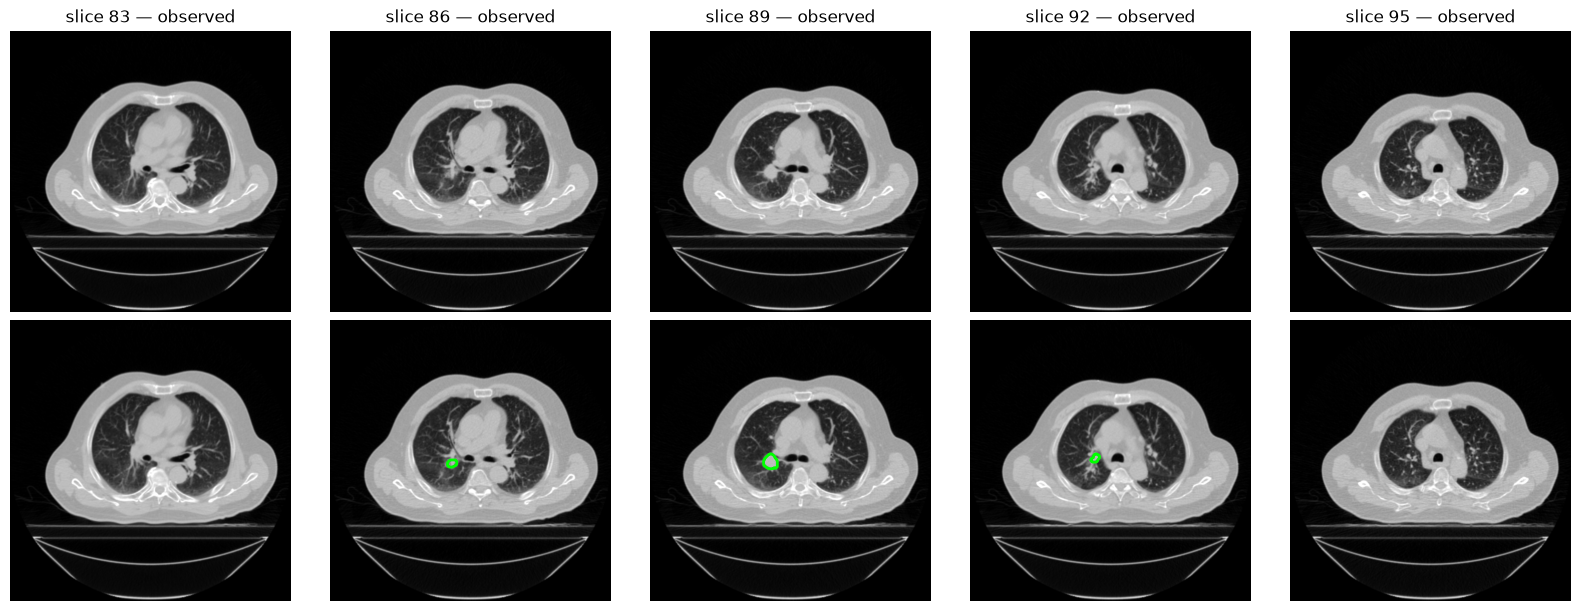

In [4]:
import matplotlib.pyplot as plt

example_slices = [83, 86, 89, 92, 95]

print("CT and RTSTRUCT masks around the tumor:")

figure, axes = plt.subplots(
    2,
    len(example_slices),
    figsize=(16, 6),
    constrained_layout=True,
)

for column, slice_index in enumerate(example_slices):
    status = "observed" if slice_index in observed_set else "missing"
    ct_slice = window_hu_to_uint8(ct_hu[slice_index], study.hu_window)

    axes[0, column].imshow(ct_slice, cmap="gray")
    axes[0, column].set_title(f"slice {slice_index} — {status}")

    axes[1, column].imshow(ct_slice, cmap="gray")
    if reference_mask[slice_index].any():
        axes[1, column].contour(
            reference_mask[slice_index],
            levels=[0.5],
            colors="lime",
            linewidths=2,
        )

    for axis in axes[:, column]:
        axis.axis("off")

figure.savefig(
    FULL_ROOT / "input_tumor_region.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()


# 2. Parameters and loss functions

### Parameters

- **stride** ($s=3$): distance in original CT slice indices between consecutive regular observed training frames. The added boundary slice `0` is the only exception.
- **poly_degree** ($p=7$): degree of the polynomial parameterization used by MedGS to vary Gaussian parameters along the frame coordinate.
- **$\lambda_{\mathrm{img}}$ and $\lambda_{\mathrm{seg}}$**: outer weights of the image and segmentation branches in the joint objective. Here they are fixed to `1` and `2`.
- **$\alpha$**: relative position of an in-between render between two observed endpoint frames. Here $\alpha \in [0.2,0.8]$, where $\alpha=0$ is the left endpoint and $\alpha=1$ is the right endpoint.
- **mask threshold** ($\tau=150$): cutoff used to convert rendered segmentation scores in $[0,255]$ into binary masks for the main 2D evaluation.
- **mesh threshold**: mesh reconstruction uses the upstream MedGS automatic threshold with `--thresh 0`; this is separate from the 2D mask threshold.

### Joint image and segmentation branches

The `joint` MedGS pipeline uses a **shared Gaussian representation** with two outputs:

- the **image branch** reconstructs CT intensities;
- the **segmentation branch** reconstructs the tumor mask.

The two branches are optimized together. The image and segmentation losses therefore both influence the shared Gaussian representation.

### Image loss

The image branch uses:

$$
\mathcal{L}_{\mathrm{img}}
=
2\mathcal{L}_{1,\mathrm{img}}
+
0.5\mathcal{L}_{1,\mathrm{img}}^{\mathrm{inter}}
+
0.25\mathcal{L}_{\sigma}
+
0.25(1-\mathrm{SSIM})
$$

The terms have different roles:

- $\mathcal{L}_{1,\mathrm{img}}$ measures the absolute pixel-wise reconstruction error on observed CT frames;
- $\mathcal{L}_{1,\mathrm{img}}^{\mathrm{inter}}$ applies the same type of error to an image rendered at a sampled position between observed frames;
- $\mathcal{L}_{\sigma}$ regularizes the Gaussian extent along the frame coordinate;
- SSIM measures local structural similarity, so $1-\mathrm{SSIM}$ penalizes structural disagreement even when pixel-wise errors are small.

### Segmentation loss on observed frames

For an observed ground-truth mask $M$ and rendered segmentation $\hat{M}$, the Dice loss is:

$$
\mathcal{L}_{\mathrm{Dice}}
=
1-
\frac{2\sum \hat{M}M+\varepsilon}
{\sum \hat{M}+\sum M+\varepsilon}
$$

Dice is useful here because the tumor occupies only a very small fraction of a $512 \times 512$ slice. It directly rewards overlap of the foreground regions instead of allowing the large background to dominate the objective.

The segmentation loss on observed frames is:

$$
\mathcal{L}_{\mathrm{seg}}^{\mathrm{obs}}
=
2\mathcal{L}_{1,\mathrm{seg}}
+
\mathcal{L}_{\mathrm{Dice}}
+
0.5\mathcal{L}_{\sigma}
$$

Here:

- $\mathcal{L}_{1,\mathrm{seg}}$ measures pixel-wise disagreement with the observed binary mask;
- $\mathcal{L}_{\mathrm{Dice}}$ encourages correct tumor overlap;
- $\mathcal{L}_{\sigma}$ regularizes the same shared Gaussian representation used by both branches.

### In-between background loss

The observed segmentation masks tell us more than only the tumor shape. An **empty observed mask** also tells us where tumor foreground should disappear.

Let:

- $A$ = left observed endpoint mask;
- $B$ = right observed endpoint mask;
- $\hat{M}_{\alpha}$ = segmentation rendered at an intermediate position $\alpha$ between them.

The additional loss is:

$$
\mathcal{L}_{\mathrm{bg,inter}}
=
w(A,B,\alpha)
\cdot
\mathrm{mean}(|\hat{M}_{\alpha}|)
$$

The function $w(A,B,\alpha)$ is fixed by the type of interval:

| Interval between observed masks | Weight |
|---|---:|
| empty $\rightarrow$ empty | $1$ |
| empty $\rightarrow$ tumor | $(1-\alpha)^2$ |
| tumor $\rightarrow$ empty | $\alpha^2$ |
| tumor $\rightarrow$ tumor | $0$ |

Interpretation:

- **empty $\rightarrow$ empty:** both endpoints contain no tumor, so foreground is penalized across the entire interval;
- **empty $\rightarrow$ tumor:** foreground is penalized most strongly near the known empty endpoint and progressively less strongly toward the tumor endpoint;
- **tumor $\rightarrow$ empty:** the symmetric case; the penalty becomes stronger as the render approaches the known empty endpoint;
- **tumor $\rightarrow$ tumor:** no background penalty is imposed, because the unknown intermediate tumor shape should be reconstructed rather than invented by a synthetic target.

This is deliberately weaker than linearly interpolating tumor masks. It uses reliable information about **absence of tumor** without assuming what the unknown intermediate tumor contour should look like.

The complete segmentation loss is:

$$
\mathcal{L}_{\mathrm{seg}}
=
\mathcal{L}_{\mathrm{seg}}^{\mathrm{obs}}
+
0.5\mathcal{L}_{\mathrm{bg,inter}}
$$

The coefficient `0.5` controls the strength of the background-aware term **inside the segmentation objective**.

### Final joint loss

The complete joint objective is:

$$
\mathcal{L}_{\mathrm{joint}}
=
\lambda_{\mathrm{img}}\mathcal{L}_{\mathrm{img}}
+
\lambda_{\mathrm{seg}}\mathcal{L}_{\mathrm{seg}}
$$

For this final experiment:

$$
\lambda_{\mathrm{img}} = 1,
\qquad
\lambda_{\mathrm{seg}} = 2
$$

so the full segmentation objective has twice the outer weight of the image objective. The loss definition and all other training parameters remain fixed throughout this notebook.

# 3. What the full-phase experiment tests

The local experiments were used to choose the MedGS configuration. This notebook asks a different question:

> Does the selected sparse-slice MedGS configuration still reconstruct the tumor sensibly when trained as part of the **complete CT phase**, rather than only on a short local sequence around the lesion?

The full-volume setting is important because MedGS now sees the real spatial context before and after the tumor, including many observed empty masks.

Evaluation is performed at two levels:

- **2D reconstruction:** image quality and segmentation quality on held-out slices, with special attention to held-out tumor slices `87`, `88`, `90`, `91`;
- **3D reconstruction:** the dense predicted mask stack is converted to a tumor mesh with the original upstream MedGS `slices_to_ply.py` procedure and compared with the reference mesh.

No full-phase hyperparameter selection is performed. Threshold sweeps below are diagnostic and the main reported 2D result continues to use threshold `150`.

# 4. Private MedGS training script

The upstream MedGS repository is kept unchanged.

The notebook creates a **private copy of `train.py` inside the experiment results directory** and patches only the behavior required for this experiment:

- Dice loss for observed segmentation masks;
- the background-aware in-between segmentation term;
- CSV histories for image loss, segmentation loss and the additional background term.

The original MedGS joint training, rendering pipeline and Gaussian representation are otherwise retained. This makes the experiment reproducible without turning the upstream repository into a project-specific fork.

In [5]:
def build_full_phase_train_script() -> Path:
    """Create a private MedGS train.py with Dice and background-aware in-between loss."""

    TOOLS_DIR.mkdir(parents=True, exist_ok=True)

    source = (MEDGS_REPO / "train.py").read_text(
        encoding="utf-8"
    )

    if "import csv\n" not in source:
        source = source.replace(
            "import os\n",
            "import os\nimport csv\n",
            1,
        )

    joint_start = source.index("def training_joint(")
    joint_end = source.index(
        "def prepare_output_and_logger",
        joint_start,
    )
    joint_source = source[joint_start:joint_end]

    # Replace only the segmentation section inside training_joint().
    # Using start/end anchors is less brittle than matching the whole
    # upstream block line-for-line.
    seg_start = joint_source.index(
        "        outputs_seg = {}\n"
    )
    seg_end = joint_source.index(
        '        render_seg_curr = outputs_seg["camera"]["render"]\n',
        seg_start,
    )

    seg_lines = [
        "        seg_bg_inter_terms = []",
        "",
        "        if interpolation > 1:",
        "            seg_intervals = []",
        "",
        "            if cam_prev_seg is not None:",
        "                seg_intervals.append((",
        "                    cam_prev_seg,",
        "                    gts_seg[idx - prev_next_overlap],",
        "                    gts_seg[idx],",
        "                ))",
        "",
        "            if cam_next_seg is not None:",
        "                seg_intervals.append((",
        "                    cam_seg,",
        "                    gts_seg[idx],",
        "                    gts_seg[idx + prev_next_overlap],",
        "                ))",
        "",
        "            for inter_cam, A_seg, B_seg in seg_intervals:",
        f"                alpha_seg = np.random.uniform({ALPHA_MIN}, {ALPHA_MAX})",
        "",
        "                A_empty = bool((A_seg > 0.5).sum().item() == 0)",
        "                B_empty = bool((B_seg > 0.5).sum().item() == 0)",
        "",
        "                if A_empty and B_empty:",
        "                    bg_weight = 1.0",
        "                elif A_empty and not B_empty:",
        "                    bg_weight = (1.0 - alpha_seg) ** 2",
        "                elif not A_empty and B_empty:",
        "                    bg_weight = alpha_seg ** 2",
        "                else:",
        "                    bg_weight = 0.0",
        "",
        "                if bg_weight > 0.0:",
        "                    rpkg_inter_seg = render(",
        "                        inter_cam,",
        "                        gaussians,",
        "                        pipe,",
        "                        bg,",
        "                        train=True,",
        "                        iter=iteration,",
        "                        seg=True,",
        '                        head="seg",',
        "                        alpha=alpha_seg,",
        "                    )",
        "",
        "                    inter_seg = rpkg_inter_seg[\"render\"].clamp(0.0, 1.0)",
        "                    seg_bg_inter_terms.append(",
        "                        float(bg_weight) * inter_seg.abs().mean()",
        "                    )",
        "",
        "        outputs_seg = {}",
        "        for name, cam in cameras_seg.items():",
        "            if cam is None:",
        "                continue",
        '            rpkg = render(cam, gaussians, pipe, bg, train=True, iter=iteration, seg=True, head="seg")',
        '            if name == "camera_prev":',
        '                rpkg["gt"] = gts_seg[idx - prev_next_overlap]',
        '            elif name == "camera":',
        '                rpkg["gt"] = gts_seg[idx]',
        "            else:",
        '                rpkg["gt"] = gts_seg[idx + prev_next_overlap]',
        "            outputs_seg[name] = rpkg",
        "",
        "        data_seg = {}",
        '        for k in outputs_seg["camera"].keys():',
        '            if k == "viewspace_points":',
        "                data_seg[k] = [o[k] for o in outputs_seg.values()]",
        '            elif k in ["visibility_filter", "radii"]:',
        "                data_seg[k] = [o[k] for o in outputs_seg.values()]",
        '            elif k in ["render", "gt", "mask"]:',
        "                data_seg[k] = torch.stack([o[k] for o in outputs_seg.values()], dim=0)",
        "",
        '        Ll1_seg = l1_loss(data_seg["render"], data_seg["gt"])',
        '        seg_pred = data_seg["render"].clamp(0.0, 1.0)',
        '        seg_gt = data_seg["gt"].clamp(0.0, 1.0)',
        "",
        "        dice_dims = tuple(range(1, seg_pred.ndim))",
        "        dice_intersection = (seg_pred * seg_gt).sum(dim=dice_dims)",
        "        dice_denominator = seg_pred.sum(dim=dice_dims) + seg_gt.sum(dim=dice_dims)",
        "        dice_loss_seg = 1.0 - (",
        "            (2.0 * dice_intersection + 1e-6)",
        "            / (dice_denominator + 1e-6)",
        "        ).mean()",
        "",
        "        if seg_bg_inter_terms:",
        "            L_bg_inter = torch.stack(seg_bg_inter_terms).mean()",
        "        else:",
        "            L_bg_inter = torch.tensor(",
        "                0.0,",
        '                device=data_seg["render"].device,',
        '                dtype=data_seg["render"].dtype,',
        "            )",
        "",
        "        loss_seg = (",
        "            2.0 * Ll1_seg",
        f"            + {DICE_WEIGHT} * dice_loss_seg",
        "            + 0.5 * sigma_loss",
        f"            + {BG_INTER_WEIGHT} * L_bg_inter",
        "        )",
        "",
    ]

    seg_replacement = "\n".join(seg_lines)

    joint_source = (
        joint_source[:seg_start]
        + seg_replacement
        + joint_source[seg_end:]
    )

    # Add CSV history initialization immediately before the joint loop.
    loop_anchor = (
        "    for iteration in range(first_iter, opt.iterations + 1):\n"
    )
    loop_pos = joint_source.index(loop_anchor)

    history_lines = [
        '    history_dir = os.path.join(scene_img.model_path, "history")',
        "    os.makedirs(history_dir, exist_ok=True)",
        "",
        '    train_history_path = os.path.join(history_dir, "train_l1.csv")',
        '    test_history_path = os.path.join(history_dir, "test_l1.csv")',
        "",
        '    with open(train_history_path, "w", newline="") as fp:',
        "        writer = csv.writer(fp)",
        "        writer.writerow([",
        '            "iteration",',
        '            "img_train_l1",',
        '            "seg_train_l1",',
        '            "seg_bg_inter",',
        '            "img_train_total",',
        '            "seg_train_total",',
        '            "joint_train_total",',
        "        ])",
        "",
        '    with open(test_history_path, "w", newline="") as fp:',
        "        writer = csv.writer(fp)",
        '        writer.writerow(["iteration", "head", "test_l1"])',
        "",
        "",
    ]
    history_setup = "\n".join(history_lines)

    joint_source = (
        joint_source[:loop_pos]
        + history_setup
        + joint_source[loop_pos:]
    )

    # Log the joint losses before backward().
    joint_loss_line = (
        "        loss = lambda_img * loss_img + lambda_seg * loss_seg\n"
    )
    loss_pos = joint_source.index(joint_loss_line)
    backward_pos = joint_source.index(
        "        loss.backward()\n",
        loss_pos,
    )

    train_log_lines = [
        "",
        f"        if iteration % {TRAIN_HISTORY_INTERVAL} == 0 or iteration == opt.iterations:",
        '            with open(train_history_path, "a", newline="") as fp:',
        "                writer = csv.writer(fp)",
        "                writer.writerow([",
        "                    iteration,",
        "                    float(Ll1_img.detach().item()),",
        "                    float(Ll1_seg.detach().item()),",
        "                    float(L_bg_inter.detach().item()),",
        "                    float(loss_img.detach().item()),",
        "                    float(loss_seg.detach().item()),",
        "                    float(loss.detach().item()),",
        "                ])",
        "",
    ]
    train_log = "\n".join(train_log_lines)

    joint_source = (
        joint_source[:backward_pos]
        + train_log
        + joint_source[backward_pos:]
    )

    source = (
        source[:joint_start]
        + joint_source
        + source[joint_end:]
    )

    # Add test-L1 CSV logging in training_report().
    report_start = source.index("def training_report(")
    report_end = source.index(
        'if __name__ == "__main__":',
        report_start,
    )
    report_source = source[report_start:report_end]

    report_anchor = (
        "        psnr_test /= len(config['cameras'])\n"
        "        l1_test /= len(config['cameras'])\n"
    )
    report_pos = report_source.index(report_anchor)
    report_insert_pos = report_pos + len(report_anchor)

    report_log_lines = [
        "",
        '        history_dir = os.path.join(scene.model_path, "history")',
        "        os.makedirs(history_dir, exist_ok=True)",
        '        test_history_path = os.path.join(history_dir, "test_l1.csv")',
        "",
        '        with open(test_history_path, "a", newline="") as fp:',
        "            writer = csv.writer(fp)",
        "            writer.writerow([",
        "                iteration,",
        "                plot_prefix,",
        "                float(l1_test),",
        "            ])",
        "",
    ]
    report_log = "\n".join(report_log_lines)

    report_source = (
        report_source[:report_insert_pos]
        + report_log
        + report_source[report_insert_pos:]
    )

    source = (
        source[:report_start]
        + report_source
        + source[report_end:]
    )

    # Validate the generated script before saving it.
    compile(
        source,
        str(PATCHED_TRAIN),
        "exec",
    )

    PATCHED_TRAIN.write_text(
        source,
        encoding="utf-8",
    )

    return PATCHED_TRAIN


build_full_phase_train_script()

print("Private MedGS training script prepared:", PATCHED_TRAIN)


Private MedGS training script prepared: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/tools/train_joint_bginter_v13_full_phase.py


# 5. Full-phase training and evaluation pipeline

The pipeline is intentionally the same for the whole final run:

1. build sparse CT and mask datasets from the observed slices only;
2. train one joint MedGS model for 30,000 iterations;
3. render CT and segmentation predictions densely over slices `0..146`;
4. compare reconstructed CT with the original CT;
5. threshold rendered segmentation scores at `150` for the primary 2D mask evaluation;
6. reconstruct the tumor mesh using the upstream MedGS marching-cubes pipeline;
7. save numerical results and figures under one experiment directory.

Observed and held-out slices are reported separately. This prevents excellent reconstruction of training slices from hiding poor interpolation on missing slices.

In [6]:
def render_source_for_slice(slice_index: int) -> tuple[int, int]:
    observed_array = np.asarray(observed_slices, dtype=int)

    exact = np.flatnonzero(observed_array == slice_index)
    if len(exact):
        return int(exact[0]), 0

    right = int(np.searchsorted(observed_array, slice_index))
    left = right - 1

    gap = int(observed_array[right] - observed_array[left])
    alpha = (slice_index - int(observed_array[left])) / gap
    interp_index = int(round(alpha * RENDER_INTERP))

    return left, interp_index


def build_mesh_from_scores(
    label: str,
    run_dir: Path,
    mask_scores: np.ndarray,
) -> tuple[TriangleMesh | None, dict[str, Any] | None]:
    if mask_scores.max() == mask_scores.min():
        return None, None

    mesh_input_root = run_dir / "mesh_input"
    mesh_case_dir = mesh_input_root / "case" / "render"
    mesh_output_dir = run_dir / "mesh"
    eval_dir = run_dir / "evaluation"

    shutil.rmtree(mesh_input_root, ignore_errors=True)
    shutil.rmtree(mesh_output_dir, ignore_errors=True)
    mesh_case_dir.mkdir(parents=True)
    mesh_output_dir.mkdir(parents=True)
    eval_dir.mkdir(parents=True, exist_ok=True)

    for local_index, slice_index in enumerate(evaluation_slices):
        Image.fromarray(mask_scores[local_index].astype(np.uint8)).save(
            mesh_case_dir / f"{local_index:05d}_0.png"
        )

    print(f"{label}: building tumor mesh.")

    mesh_command = [
        sys.executable,
        str(MEDGS_REPO / "slices_to_ply.py"),
        "--input", str(mesh_input_root),
        "--output", str(mesh_output_dir),
        "--thresh", str(MESH_THRESHOLD),
        "--inter", "1",
    ]

    subprocess.run(mesh_command, cwd=MEDGS_REPO, check=True)

    import open3d as o3d

    medgs_ply = mesh_output_dir / "case.ply"
    o3d_mesh = o3d.io.read_triangle_mesh(str(medgs_ply))

    vertices_zyx = np.asarray(o3d_mesh.vertices, dtype=np.float64).copy()
    faces = np.asarray(o3d_mesh.triangles, dtype=np.int64)

    vertices_xyz = geometry.index_zyx_to_patient_xyz(vertices_zyx)

    predicted_mesh = TriangleMesh(
        vertices_zyx=vertices_zyx,
        vertices_xyz=vertices_xyz,
        faces=faces,
    )

    write_ply(
        mesh_output_dir / "case_patient_coordinates.ply",
        vertices_xyz,
        faces,
    )

    mesh_metrics = evaluate_mesh_against_reference(
        predicted_mesh,
        reference_mesh,
        reference_mask,
        geometry,
    )
    mesh_metrics.pop("CandidateMask")

    serializable_metrics = {
        key: value.item() if isinstance(value, np.generic) else value
        for key, value in mesh_metrics.items()
    }

    (eval_dir / "mesh_metrics.json").write_text(
        json.dumps(serializable_metrics, indent=2, sort_keys=True),
        encoding="utf-8",
    )

    return predicted_mesh, serializable_metrics


def evaluate_masks(
    label: str,
    run_dir: Path,
    predicted_mask_scores: np.ndarray,
) -> dict[str, Any]:
    eval_dir = run_dir / "evaluation"
    eval_dir.mkdir(parents=True, exist_ok=True)

    predicted_mask = predicted_mask_scores >= MASK_THRESHOLD

    rows = []
    for local_index, slice_index in enumerate(evaluation_slices):
        gt_mask = reference_mask_eval[local_index]
        pred_mask = predicted_mask[local_index]
        scores = predicted_mask_scores[local_index]

        rows.append(
            {
                "SliceIndex": slice_index,
                "Observed": slice_index in observed_set,
                "TumorGT": bool(gt_mask.any()),
                "GTPixels": int(gt_mask.sum()),
                "PredictedPixels": int(pred_mask.sum()),
                "ScoreMax": int(scores.max()),
                "ScoreMean": float(scores.mean()),
                "Dice": binary_dice(pred_mask, gt_mask),
                "IoU": binary_iou(pred_mask, gt_mask),
            }
        )

    per_slice = pd.DataFrame(rows)
    per_slice.to_csv(eval_dir / "mask_per_slice.csv", index=False)

    missing_frame = per_slice[~per_slice["Observed"]]
    tumor_missing_frame = per_slice[
        per_slice["SliceIndex"].isin(tumor_missing_slices)
    ]
    empty_missing_frame = missing_frame[~missing_frame["TumorGT"]]

    summary_rows = []
    for name, frame in [
        ("all", per_slice),
        ("observed", per_slice[per_slice["Observed"]]),
        ("missing_all", missing_frame),
        ("tumor_missing", tumor_missing_frame),
        ("empty_missing", empty_missing_frame),
    ]:
        summary_rows.append(
            {
                "Split": name,
                "Slices": len(frame),
                "Dice": float(frame["Dice"].mean()),
                "IoU": float(frame["IoU"].mean()),
            }
        )

    summary = pd.DataFrame(summary_rows)
    summary.to_csv(eval_dir / "mask_summary.csv", index=False)

    empty_indices = [
        i for i, slice_index in enumerate(evaluation_slices)
        if slice_index not in tumor_slices
    ]
    observed_empty_indices = [
        evaluation_slices.index(i)
        for i in observed_empty_slices
    ]

    false_positive_pixels = int(predicted_mask[empty_indices].sum())
    positive_empty_slices = int(
        predicted_mask[empty_indices]
        .reshape(len(empty_indices), -1)
        .any(axis=1)
        .sum()
    )
    positive_observed_empty = int(
        predicted_mask[observed_empty_indices]
        .reshape(len(observed_empty_indices), -1)
        .any(axis=1)
        .sum()
    )

    extent = {
        "FalsePositivePixelsOutsideTumor": false_positive_pixels,
        "PositiveSlicesOutsideTumor": positive_empty_slices,
        "PositiveObservedEmptySlices": positive_observed_empty,
    }

    (eval_dir / "extent_metrics.json").write_text(
        json.dumps(extent, indent=2, sort_keys=True),
        encoding="utf-8",
    )

    predicted_mesh, mesh_metrics = build_mesh_from_scores(
        label,
        run_dir,
        predicted_mask_scores,
    )

    return {
        "predicted_mask_scores": predicted_mask_scores,
        "predicted_mask": predicted_mask,
        "mask_per_slice": per_slice,
        "mask_summary": summary,
        "extent": extent,
        "predicted_mesh": predicted_mesh,
        "mesh_metrics": mesh_metrics,
    }


def run_medgs() -> dict[str, Any]:
    label = "MedGS full phase"
    run_dir = MEDGS_RUN
    model_dir = run_dir / "model"
    dense_img_dir = run_dir / "dense_img"
    dense_mask_dir = run_dir / "dense_mask"
    eval_dir = run_dir / "evaluation"

    checkpoint = model_dir / f"chkpnt{ITERATIONS}.pth"

    if FORCE_TRAIN and run_dir.exists():
        shutil.rmtree(run_dir)

    if not checkpoint.is_file() and model_dir.exists():
        shutil.rmtree(model_dir, ignore_errors=True)

    run_dir.mkdir(parents=True, exist_ok=True)

    config_record = {
        "lambda_img": LAMBDA_IMG,
        "lambda_seg": LAMBDA_SEG,
        "stride": SLICE_STRIDE,
        "poly_degree": POLY_DEGREE,
        "iterations": ITERATIONS,
        "dice_weight": DICE_WEIGHT,
        "bg_inter_weight": BG_INTER_WEIGHT,
        "alpha_min": ALPHA_MIN,
        "alpha_max": ALPHA_MAX,
        "mask_threshold": MASK_THRESHOLD,
        "range_start": RANGE_START,
        "range_end": RANGE_END,
        "observed_slices": observed_slices,
        "tumor_slices": tumor_slices,
    }

    (run_dir / "experiment_config.json").write_text(
        json.dumps(config_record, indent=2, sort_keys=True),
        encoding="utf-8",
    )

    train_command = [
        sys.executable,
        str(PATCHED_TRAIN),
        "-s", str(IMG_DATASET),
        "-m", str(model_dir),
        "--pipeline", "joint",
        "--seg_source_path", str(MASK_DATASET),
        "--lambda_img", str(LAMBDA_IMG),
        "--lambda_seg", str(LAMBDA_SEG),
        "--iterations", str(ITERATIONS),
        "--save_iterations", str(ITERATIONS),
        "--test_iterations", *[str(v) for v in TEST_ITERATIONS],
        "--checkpoint_iterations", str(ITERATIONS),
        "--poly_degree", str(POLY_DEGREE),
        "--batch_size", str(BATCH_SIZE),
        "--camera", "mirror",
    ]

    if checkpoint.is_file():
        print(f"{label}: reusing checkpoint.")
    else:
        print(f"{label}: training.")
        env = os.environ.copy()
        env["PYTHONPATH"] = (
            str(MEDGS_REPO)
            + os.pathsep
            + env.get("PYTHONPATH", "")
        )
        subprocess.run(
            train_command,
            cwd=MEDGS_REPO,
            env=env,
            check=True,
        )

    assert checkpoint.is_file(), checkpoint

    for folder in (model_dir / "render_img", model_dir / "render_mask"):
        shutil.rmtree(folder, ignore_errors=True)

    print(f"{label}: rendering CT and masks.")

    render_command = [
        sys.executable,
        str(MEDGS_REPO / "render.py"),
        "--model_path", str(model_dir),
        "--iteration", str(ITERATIONS),
        "--interp", str(RENDER_INTERP),
        "--pipeline", "both",
        "--chunks", str(RENDER_CHUNKS),
        "--poly_degree", str(POLY_DEGREE),
        "--camera", "mirror",
    ]

    subprocess.run(render_command, cwd=MEDGS_REPO, check=True)

    for folder in (dense_img_dir, dense_mask_dir):
        shutil.rmtree(folder, ignore_errors=True)
        folder.mkdir(parents=True)

    mapping_rows = []

    for slice_index in evaluation_slices:
        frame_index, interp_index = render_source_for_slice(slice_index)
        source_name = f"{frame_index:05d}_{interp_index}.png"

        img_source = model_dir / "render_img" / source_name
        mask_source = model_dir / "render_mask" / source_name

        assert img_source.is_file(), img_source
        assert mask_source.is_file(), mask_source

        target_name = f"{slice_index:04d}.png"
        shutil.copy2(img_source, dense_img_dir / target_name)
        shutil.copy2(mask_source, dense_mask_dir / target_name)

        mapping_rows.append(
            {
                "SliceIndex": slice_index,
                "Observed": slice_index in observed_set,
                "MedGSFrame": frame_index,
                "InterpIndex": interp_index,
            }
        )

    render_mapping = pd.DataFrame(mapping_rows)
    render_mapping.to_csv(run_dir / "render_mapping.csv", index=False)

    predicted_ct = np.stack(
        [
            np.asarray(
                Image.open(dense_img_dir / f"{i:04d}.png").convert("L"),
                dtype=np.float32,
            ) / 255.0
            for i in evaluation_slices
        ]
    )

    predicted_mask_scores = np.stack(
        [
            np.asarray(
                Image.open(dense_mask_dir / f"{i:04d}.png").convert("L"),
                dtype=np.uint8,
            )
            for i in evaluation_slices
        ]
    )

    image_rows = []
    for local_index, slice_index in enumerate(evaluation_slices):
        metrics = calculate_reconstruction_metrics(
            torch.from_numpy(predicted_ct[local_index]),
            torch.from_numpy(ground_truth_ct[local_index]),
        )
        image_rows.append(
            {
                "SliceIndex": slice_index,
                "Observed": slice_index in observed_set,
                **metrics,
            }
        )

    image_per_slice = pd.DataFrame(image_rows)
    eval_dir.mkdir(parents=True, exist_ok=True)
    image_per_slice.to_csv(eval_dir / "image_per_slice.csv", index=False)

    image_summary_rows = []
    for name, frame in [
        ("all", image_per_slice),
        ("observed", image_per_slice[image_per_slice["Observed"]]),
        ("missing_all", image_per_slice[~image_per_slice["Observed"]]),
        (
            "tumor_missing",
            image_per_slice[
                image_per_slice["SliceIndex"].isin(tumor_missing_slices)
            ],
        ),
    ]:
        image_summary_rows.append(
            {
                "Split": name,
                "Slices": len(frame),
                **{
                    metric: float(frame[metric].mean())
                    for metric in ["L1", "PSNR", "SSIM"]
                },
            }
        )

    image_summary = pd.DataFrame(image_summary_rows)
    image_summary.to_csv(eval_dir / "image_summary.csv", index=False)

    mask_result = evaluate_masks(label, run_dir, predicted_mask_scores)

    return {
        "label": label,
        "run_dir": run_dir,
        "model_dir": model_dir,
        "eval_dir": eval_dir,
        "predicted_ct": predicted_ct,
        "image_per_slice": image_per_slice,
        "image_summary": image_summary,
        **mask_result,
    }


print("Full-phase MedGS pipeline ready.")


Full-phase MedGS pipeline ready.


In [7]:
medgs_result = run_medgs()

print("MedGS image reconstruction metrics:")
display(medgs_result["image_summary"])

print("MedGS mask reconstruction metrics:")
display(medgs_result["mask_summary"])

print("MedGS held-out tumor slices:")
display(
    medgs_result["mask_per_slice"][
        medgs_result["mask_per_slice"]["SliceIndex"].isin(tumor_missing_slices)
    ][["SliceIndex", "GTPixels", "PredictedPixels", "Dice", "IoU"]]
)

print("MedGS mask extent:")
display(pd.DataFrame([medgs_result["extent"]]))

print("MedGS mesh reconstruction metrics:")
display(
    pd.DataFrame({"Value": medgs_result["mesh_metrics"]}).rename_axis("Metric")
)


MedGS full phase: training.
torch cuda:  True
Optimizing /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/medgs/model
Training with JOINT img+seg loss (no freezing) [02/09 13:09:51]
Output folder: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/medgs/model [02/09 13:09:51]
Tensorboard not available: not logging progress [02/09 13:09:51]
frames(img) 50 [02/09 13:09:51]
frames(seg) 50 [02/09 13:09:51]
Distance: 1.0 [02/09 13:09:51]
Creating Training Transforms [02/09 13:09:51]
Creating Test Transforms [02/09 13:09:53]
AAAAA radius 1.1 [02/09 13:09:54]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [02/09 13:09:54]
Generating random point cloud (100000)... [02/09 13:09:54]
Loading Training Cameras [02/09 13:09:55]
Loading Test Cameras [02/09 13:09:55]
Number of points at initialisation :  100000 [02/09 13:09:55]
NOT U

Training progress: 100%|██████████| 30000/30000 [37:02<00:00, 13.50it/s, Loss=0.0188371, psnr_img=45.31, psnr_seg=inf, point=281268]   


prev_next_overlap 2 [02/09 13:09:59]

[ITER 5000] (img) Evaluating test: L1 0.008373774532228708 PSNR 35.71509712219238 [02/09 13:13:48]

[ITER 5000] (seg) Evaluating test: L1 0.00019261183344491785 PSNR inf [02/09 13:13:48]
changed interpolation [02/09 13:18:18]

[ITER 10000] (img) Evaluating test: L1 0.005925822118297219 PSNR 39.95155426025391 [02/09 13:18:18]

[ITER 10000] (seg) Evaluating test: L1 5.445670188723995e-05 PSNR inf [02/09 13:18:19]

[ITER 15000] (img) Evaluating test: L1 0.005412709265947342 PSNR 41.09077072143555 [02/09 13:25:23]

[ITER 15000] (seg) Evaluating test: L1 2.1484179058006703e-05 PSNR inf [02/09 13:25:23]

[ITER 20000] (img) Evaluating test: L1 0.005295062395744026 PSNR 41.55198020935059 [02/09 13:32:59]

[ITER 20000] (seg) Evaluating test: L1 1.606636050089705e-05 PSNR inf [02/09 13:33:00]

[ITER 25000] (img) Evaluating test: L1 0.005025922027416528 PSNR 42.05550552368164 [02/09 13:40:02]

[ITER 25000] (seg) Evaluating test: L1 7.676384857404628e-06 PSNR 

/home/jovyan/shared/mtm_medgs_stack/repo/MedGS/render.py:168: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state, loaded_iter = torch.load(ckpt_path, map_location="cu

Looking for config file in /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/medgs/model/cfg_args
Config file found: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/medgs/model/cfg_args
Rendering /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/medgs/model
Distance: 1.0 [02/09 13:47:06]
Loading trained model at iteration 30000 [02/09 13:47:06]
Creating Training Transforms [02/09 13:47:06]
Creating Test Transforms [02/09 13:47:08]
AAAAA radius 1.1 [02/09 13:47:09]
AAAAA translate [-0. -0. -0.] center [0. 0. 0.] [02/09 13:47:09]
Generating random point cloud (100000)... [02/09 13:47:09]
Loading Training Cameras [02/09 13:47:09]
Loading Test Cameras [02/09 13:47:10]
Loading checkpoint: /home/jovyan/shared/mtm_medgs_stack/results/canoni

...

,SliceIndex,GTPixels,PredictedPixels,Dice,IoU
87,87,581,194,0.500645,0.333907
88,88,583,407,0.818182,0.692308
90,90,422,453,0.873143,0.774848
91,91,385,176,0.509804,0.342105


MedGS mask extent:


,FalsePositivePixelsOutsideTumor,PositiveSlicesOutsideTumor,PositiveObservedEmptySlices
0,487,8,2


MedGS mesh reconstruction metrics:


,Value
Metric,
Dice,0.457198
IoU,0.296342
MeanSurfaceDistanceMm,5.476286
HD95Mm,19.643478
CentroidErrorMm,0.83077
VolumeMm3,24591.717006
ReferenceVolumeMm3,8020.063232
VolumeErrorMm3,16571.653774
VolumeErrorPercent,206.62747


### Reading the numerical summaries

The main mask split is **`tumor_missing`**: the four tumor-containing slices that were deliberately hidden from MedGS during training.

Other splits have complementary roles:

- **`observed`** checks whether the model fitted the sparse training masks;
- **`missing_all`** summarizes all reconstructed slices;
- **`empty_missing`** measures behavior on missing slices where the ground-truth mask is empty.

For tumor reconstruction:

- **Dice** and **IoU** measure overlap of predicted and ground-truth foreground;
- larger values are better.

For the 3D mesh:

- **Mesh Dice / IoU** measure volumetric overlap;
- **Mean Surface Distance** measures the average surface discrepancy in millimetres;
- **HD95** is the 95th-percentile Hausdorff distance and captures larger boundary errors without being dominated by a single extreme outlier;
- **Centroid Error** measures displacement of the reconstructed tumor centre;
- **Volume Error Percent** shows under- or over-estimation of total tumor volume.

MedGS image train/test L1:


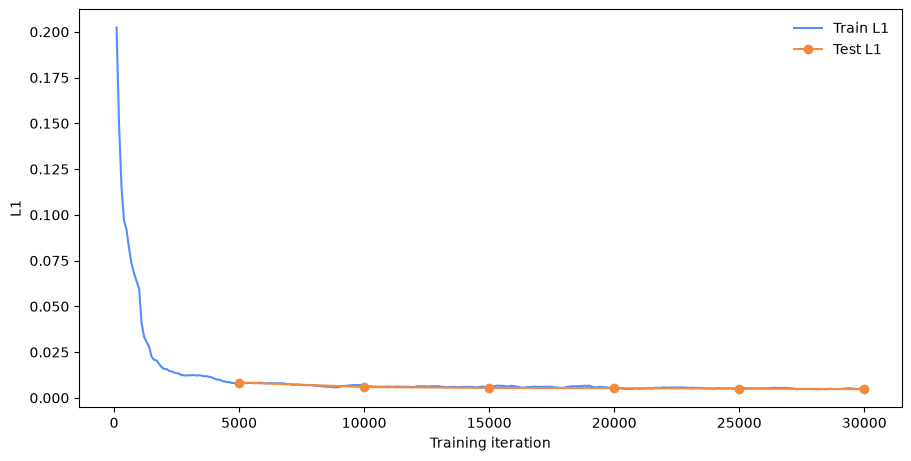

MedGS segmentation train/test L1:


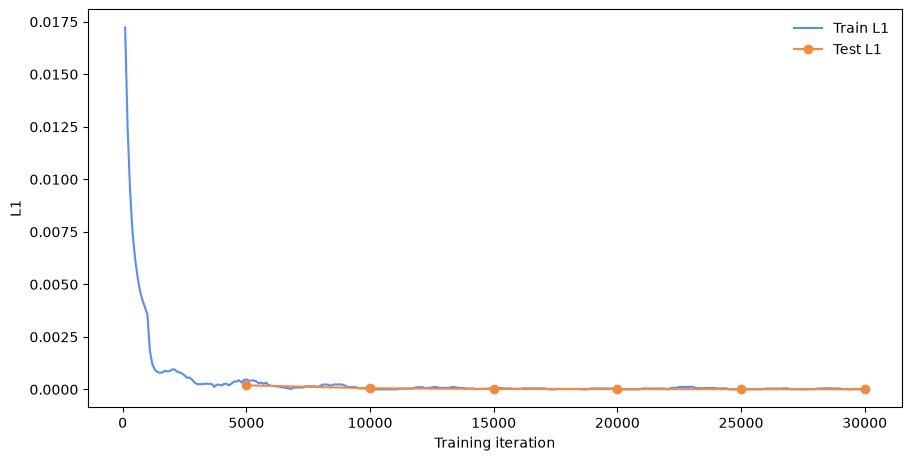

Background-aware in-between loss:


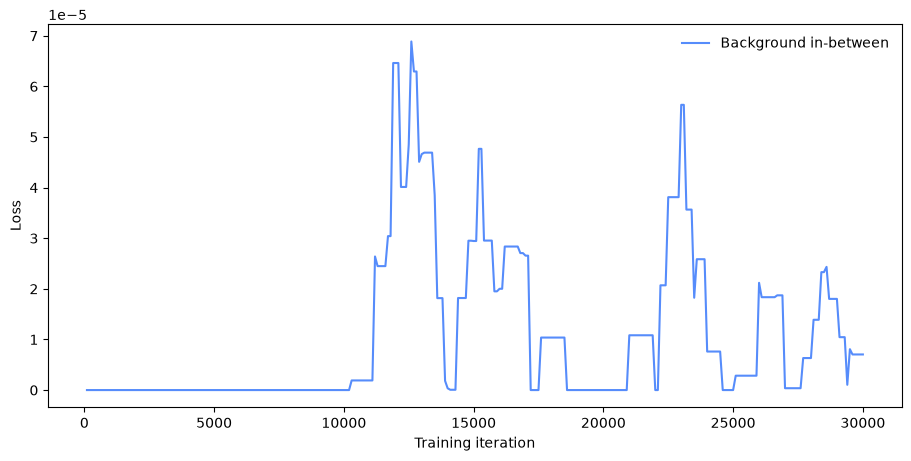

In [8]:
import matplotlib.pyplot as plt

train_history = pd.read_csv(
    medgs_result["model_dir"] / "history" / "train_l1.csv"
)
test_history = pd.read_csv(
    medgs_result["model_dir"] / "history" / "test_l1.csv"
)

train_history["img_l1_smooth"] = (
    train_history["img_train_l1"].rolling(window=10, min_periods=1).mean()
)
train_history["seg_l1_smooth"] = (
    train_history["seg_train_l1"].rolling(window=10, min_periods=1).mean()
)
train_history["bg_inter_smooth"] = (
    train_history["seg_bg_inter"].rolling(window=10, min_periods=1).mean()
)

img_test = test_history[test_history["head"] == "img"]
seg_test = test_history[test_history["head"] == "seg"]

print("MedGS image train/test L1:")
figure, axis = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
axis.plot(train_history["iteration"], train_history["img_l1_smooth"], label="Train L1")
axis.plot(img_test["iteration"], img_test["test_l1"], marker="o", label="Test L1")
axis.set_xlabel("Training iteration")
axis.set_ylabel("L1")
axis.legend(frameon=False)
figure.savefig(
    medgs_result["eval_dir"] / "img_train_test_l1.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()

print("MedGS segmentation train/test L1:")
figure, axis = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
axis.plot(train_history["iteration"], train_history["seg_l1_smooth"], label="Train L1")
axis.plot(seg_test["iteration"], seg_test["test_l1"], marker="o", label="Test L1")
axis.set_xlabel("Training iteration")
axis.set_ylabel("L1")
axis.legend(frameon=False)
figure.savefig(
    medgs_result["eval_dir"] / "seg_train_test_l1.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()

print("Background-aware in-between loss:")
figure, axis = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
axis.plot(
    train_history["iteration"],
    train_history["bg_inter_smooth"],
    label="Background in-between",
)
axis.set_xlabel("Training iteration")
axis.set_ylabel("Loss")
axis.legend(frameon=False)
figure.savefig(
    medgs_result["eval_dir"] / "background_in_between_loss.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()


# 6. Final diagnostics

The following diagnostics answer different questions and should not be collapsed into a single score.

### Threshold sensitivity

The segmentation head produces continuous scores. Threshold `150` remains the predefined operating point used for the main comparison.

The threshold sweep is shown only to reveal the trade-off between:

- retaining tumor foreground on the held-out tumor slices;
- suppressing false-positive foreground outside the true tumor range.

It is therefore a **sensitivity analysis**, not a second round of threshold tuning on the final ground truth.

Full-phase threshold sensitivity:


,Threshold,TumorMissingDice,TumorMissingIoU,FalsePositivePixelsOutsideTumor,PositiveSlicesOutsideTumor,PositiveObservedEmptySlices
0,50,0.725200,0.588498,745,10,2
1,75,0.708112,0.572602,649,10,2
2,100,0.698306,0.562402,580,9,2
3,125,0.686811,0.549157,531,9,2
4,150,0.675443,0.535792,487,8,2
5,175,0.658827,0.514333,428,8,2
6,200,0.632416,0.480623,378,8,2
7,225,0.599344,0.440438,335,8,2


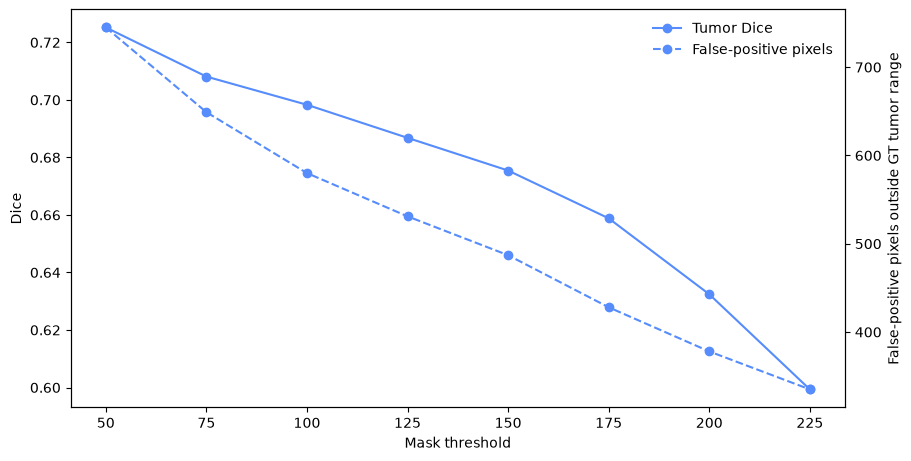

In [9]:
thresholds = [
    50, 75, 100, 125,
    150, 175, 200, 225,
]

scores = medgs_result["predicted_mask_scores"]

tumor_local_indices = [
    evaluation_slices.index(i)
    for i in tumor_missing_slices
]

empty_local_indices = [
    local_index
    for local_index, slice_index in enumerate(evaluation_slices)
    if slice_index not in tumor_slices
]

observed_empty_local_indices = [
    evaluation_slices.index(i)
    for i in observed_empty_slices
]

threshold_rows = []

for threshold in thresholds:
    mask_at_threshold = scores >= threshold

    tumor_dice = np.mean(
        [
            binary_dice(
                mask_at_threshold[i],
                reference_mask_eval[i],
            )
            for i in tumor_local_indices
        ]
    )

    tumor_iou = np.mean(
        [
            binary_iou(
                mask_at_threshold[i],
                reference_mask_eval[i],
            )
            for i in tumor_local_indices
        ]
    )

    false_positive_pixels = int(
        mask_at_threshold[empty_local_indices].sum()
    )

    positive_empty_slices = int(
        mask_at_threshold[empty_local_indices]
        .reshape(len(empty_local_indices), -1)
        .any(axis=1)
        .sum()
    )

    positive_observed_empty = int(
        mask_at_threshold[observed_empty_local_indices]
        .reshape(len(observed_empty_local_indices), -1)
        .any(axis=1)
        .sum()
    )

    threshold_rows.append(
        {
            "Threshold": threshold,
            "TumorMissingDice": float(tumor_dice),
            "TumorMissingIoU": float(tumor_iou),
            "FalsePositivePixelsOutsideTumor": false_positive_pixels,
            "PositiveSlicesOutsideTumor": positive_empty_slices,
            "PositiveObservedEmptySlices": positive_observed_empty,
        }
    )

threshold_results = pd.DataFrame(threshold_rows)
threshold_results.to_csv(
    medgs_result["eval_dir"] / "threshold_sweep.csv",
    index=False,
)

print("Full-phase threshold sensitivity:")
display(threshold_results)

figure, axis_left = plt.subplots(
    figsize=(9, 4.5),
    constrained_layout=True,
)

axis_left.plot(
    threshold_results["Threshold"],
    threshold_results["TumorMissingDice"],
    marker="o",
    label="Tumor Dice",
)
axis_left.set_xlabel("Mask threshold")
axis_left.set_ylabel("Dice")

axis_right = axis_left.twinx()
axis_right.plot(
    threshold_results["Threshold"],
    threshold_results["FalsePositivePixelsOutsideTumor"],
    marker="o",
    linestyle="--",
    label="False-positive pixels",
)
axis_right.set_ylabel("False-positive pixels outside GT tumor range")

lines = axis_left.get_lines() + axis_right.get_lines()
axis_left.legend(
    lines,
    [line.get_label() for line in lines],
    frameon=False,
    loc="best",
)

figure.savefig(
    medgs_result["eval_dir"] / "threshold_sensitivity.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

### Foreground extent along the CT axis

The next plot compares the number of tumor pixels in each slice.

This is especially informative for the failure mode seen in earlier local experiments: the reconstructed tumor could have reasonable overlap near its centre while extending too far along the slice axis.

The GT curve therefore describes both the **shape** and the **spatial support** of the tumor, while the MedGS curve shows whether reconstructed foreground appears too early, disappears too late, or misses the large central cross-sections.

GT and MedGS foreground area around the tumor:


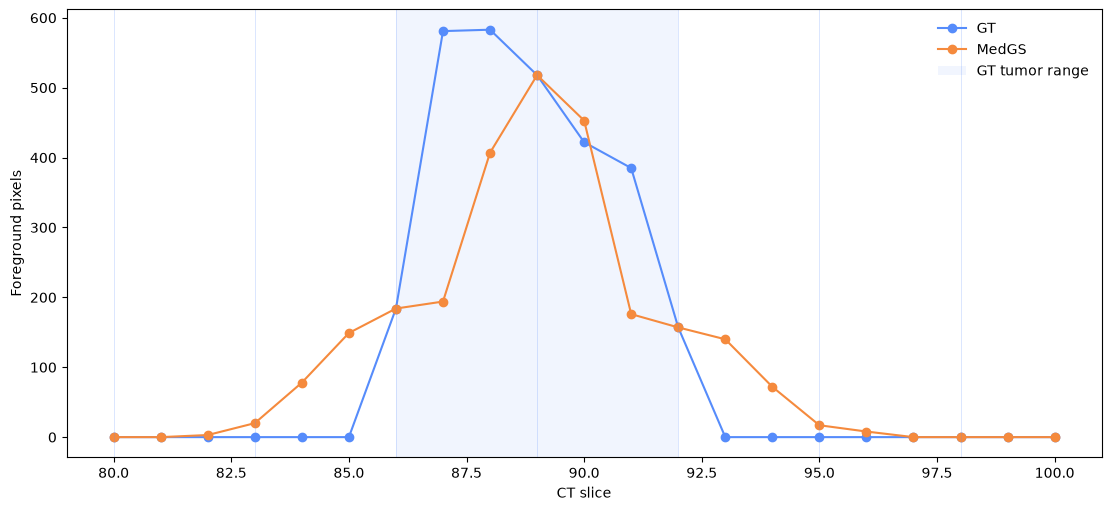

In [10]:
region_start = 80
region_end = 100

diagnostics = medgs_result["mask_per_slice"]
region = diagnostics[
    diagnostics["SliceIndex"].between(
        region_start,
        region_end,
    )
]

print("GT and MedGS foreground area around the tumor:")

figure, axis = plt.subplots(
    figsize=(11, 5),
    constrained_layout=True,
)

axis.plot(
    region["SliceIndex"],
    region["GTPixels"],
    marker="o",
    label="GT",
)
axis.plot(
    region["SliceIndex"],
    region["PredictedPixels"],
    marker="o",
    label="MedGS",
)

for slice_index in observed_slices:
    if region_start <= slice_index <= region_end:
        axis.axvline(
            slice_index,
            linewidth=0.6,
            alpha=0.25,
        )

axis.axvspan(
    TUMOR_START,
    TUMOR_END,
    alpha=0.08,
    label="GT tumor range",
)

axis.set_xlabel("CT slice")
axis.set_ylabel("Foreground pixels")
axis.legend(frameon=False)

figure.savefig(
    medgs_result["eval_dir"] / "foreground_tumor_region.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

### Held-out tumor contours

Slices `87`, `88`, `90` and `91` contain tumor in the ground truth but were not available to MedGS during training.

They are the cleanest visual test of interpolation quality:

- the top row shows the GT tumor contour in lime;
- the bottom row shows the reconstructed MedGS contour in red.

These slices should be interpreted together with Dice/IoU and the foreground-area profile rather than from appearance alone.

Held-out tumor slices: GT and MedGS contours:


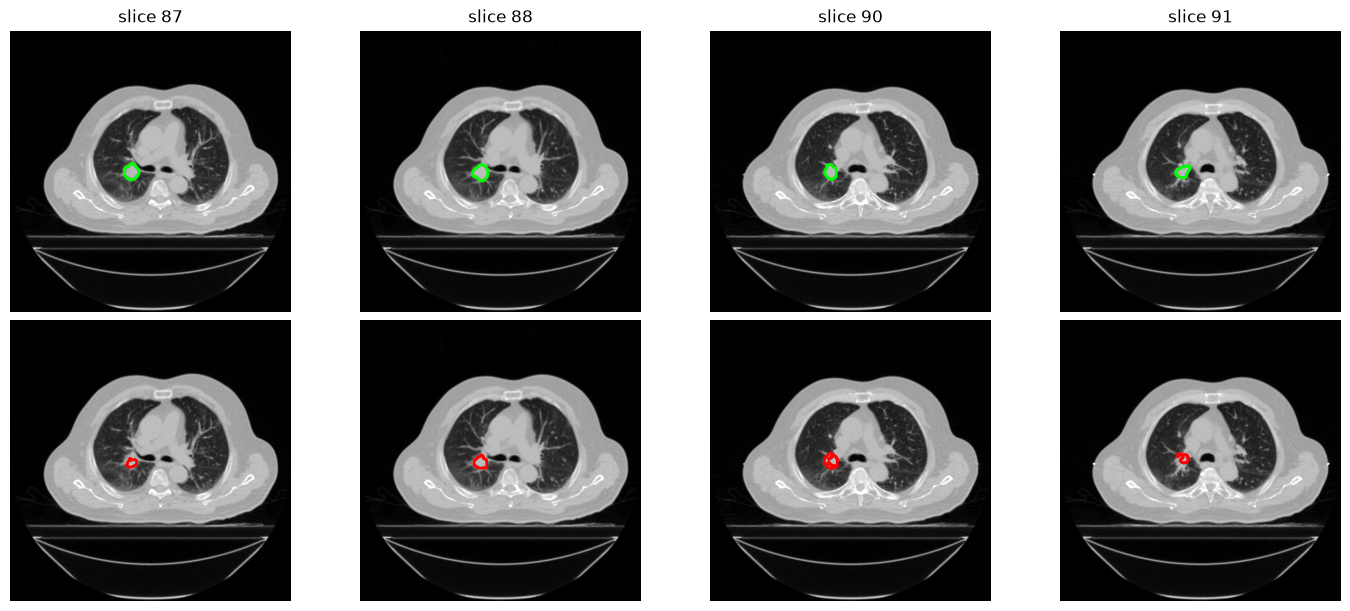

In [11]:
held_out = tumor_missing_slices

print("Held-out tumor slices: GT and MedGS contours:")

figure, axes = plt.subplots(
    2,
    len(held_out),
    figsize=(14, 6),
    constrained_layout=True,
)

for column, slice_index in enumerate(held_out):
    ct_slice = window_hu_to_uint8(
        ct_hu[slice_index],
        study.hu_window,
    )

    axes[0, column].imshow(
        ct_slice,
        cmap="gray",
    )
    axes[0, column].contour(
        reference_mask[slice_index],
        levels=[0.5],
        colors="lime",
        linewidths=2,
    )
    axes[0, column].set_title(
        f"slice {slice_index}"
    )

    axes[1, column].imshow(
        ct_slice,
        cmap="gray",
    )

    predicted = medgs_result[
        "predicted_mask"
    ][slice_index]

    if predicted.any():
        axes[1, column].contour(
            predicted,
            levels=[0.5],
            colors="red",
            linewidths=2,
        )

    for row in range(2):
        axes[row, column].axis("off")

axes[0, 0].set_ylabel(
    "GT",
    rotation=0,
    labelpad=24,
)
axes[1, 0].set_ylabel(
    "MedGS",
    rotation=0,
    labelpad=30,
)

figure.savefig(
    medgs_result["eval_dir"] / "heldout_tumor_contours.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# 7. Reconstruction views

The interactive slice browser shows the complete reconstructed phase using original CT slice indices.

It allows direct comparison of:

- ground-truth CT;
- reconstructed CT;
- ground-truth tumor mask;
- reconstructed tumor mask;
- observed versus reconstructed positions.

The 3D visualization then places the reconstructed tumor mesh next to the reference tumor mesh in anatomical context. The mesh is produced from the dense MedGS mask stack using the upstream MedGS reconstruction method, not a separate custom mesh estimator.

In [12]:
print("Full-phase CT and mask reconstruction:")

show_sparse_joint_slice_browser(
    ground_truth_ct,
    medgs_result["predicted_ct"],
    reference_mask_eval,
    medgs_result["predicted_mask"],
    observed_slices,
    slice_start=RANGE_START,
)

print("Reference and reconstructed tumor meshes:")

show_sparse_joint_anatomy_3d(
    PHASE_DIR,
    medgs_result["predicted_mesh"],
)

Full-phase CT and mask reconstruction:


Reference and reconstructed tumor meshes:


# 8. Saved outputs

All artifacts from the final MedGS run are stored under a single experiment root.

The saved outputs include:

- `observed_slices.csv` — mapping between MedGS training frames and original CT slice indices;
- `experiment_config.json` — exact final model and loss configuration;
- the private patched MedGS training script;
- the 30,000-iteration checkpoint;
- dense CT renders for the complete phase;
- dense segmentation-score renders and binary masks;
- per-slice and split-level image/segmentation metrics;
- threshold-sensitivity results;
- foreground-extent diagnostics;
- the upstream MedGS tumor mesh;
- 3D mesh metrics;
- publication-ready PNG figures.

These artifacts are sufficient for the subsequent comparison with the SDF baseline without retraining this MedGS model.

In [13]:
print("Saved experiment root:", FULL_ROOT)
print("Model:", medgs_result["model_dir"])
print("Image metrics:", medgs_result["eval_dir"] / "image_summary.csv")
print("Mask metrics:", medgs_result["eval_dir"] / "mask_summary.csv")
print("Threshold sweep:", medgs_result["eval_dir"] / "threshold_sweep.csv")
print("Mesh metrics:", medgs_result["eval_dir"] / "mesh_metrics.json")

Saved experiment root: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13
Model: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/medgs/model
Image metrics: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/medgs/evaluation/image_summary.csv
Mask metrics: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/medgs/evaluation/mask_summary.csv
Threshold sweep: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_lseg2_bginter_v13/medgs/evaluation/threshold_sweep.csv
Mesh metrics: /home/jovyan/shared/mtm_medgs_stack/results/canonical/patient117_20001024_annotated/phase00_joint_full_stride3_poly7_